# Week 9 — Operational ML: Equipment Failure Prediction
### Fleet-Wide Missed-Maintenance Risk Model

**Author:** David Kimathi
**Dataset:** `Mystery_Ops.csv` (same dataset used since Week 5)

---



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve, classification_report)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)
print("Libraries loaded (xgboost, imbalanced-learn, shap NOT available in this sandbox).")


Libraries loaded (xgboost, imbalanced-learn, shap NOT available in this sandbox).


## 1. Problem Definition

**Operational problem:** Equipment Failure Prediction. Specifically: given a depot's operating conditions on a given shift, predict whether that shift is at risk of a **missed-maintenance incident** — the same failure mode root-caused in Weeks 5–6 (pump NBI-P03).

**Target variable:** `target_failing` = 1 if `incident_type == "missed_maintenance"`, else 0.

**Why this framing, not "just flag NBI-P03":** in this dataset, every missed-maintenance incident happens on one specific machine — meaning `machine_id`, `depot`, and `maintenance_flag` are *perfect* predictors here (checked explicitly below), which would make the model trivial and useless anywhere else. A production model needs to learn from **measurable operating conditions** — throughput trend, voltage behavior — so it would still work on a *different* machine that starts failing in the future. That's the model built below: it never sees which asset it's looking at, only how that asset is behaving.


## 2. Data Prep, Feature Engineering & Imbalance Check

### 2.1 Confirming the leakage problem (and why these columns are excluded)


In [2]:
df = pd.read_csv("Mystery_Ops.csv")
df["operation_date"] = pd.to_datetime(df["operation_date"], format="%d/%m/%Y")
df["target_failing"] = (df["incident_type"] == "missed_maintenance").astype(int)

# Check: does machine_id perfectly separate the classes?
leak_check = df.groupby("machine_id", observed=True)["target_failing"].mean().sort_values(ascending=False)
print("Missed-maintenance rate by machine (top 5):")
print(leak_check.head())
print(f"\nOnly {(leak_check > 0).sum()} of {len(leak_check)} machines ever has a positive case.")

# Check: does maintenance_flag perfectly match the label?
flag_match = (df["maintenance_flag"] == df["target_failing"]).mean()
print(f"\nmaintenance_flag matches target_failing on {flag_match*100:.1f}% of rows -- unusable as a feature (it's essentially the label).")


Missed-maintenance rate by machine (top 5):
machine_id
NBI-P03    0.934629
ELD-P02    0.000000
ELD-P03    0.000000
KSM-P01    0.000000
ELD-P01    0.000000
Name: target_failing, dtype: float64

Only 1 of 13 machines ever has a positive case.

maintenance_flag matches target_failing on 99.5% of rows -- unusable as a feature (it's essentially the label).


**Confirmed:** `machine_id`/`depot` perfectly separate the classes (only one machine ever fails), and `maintenance_flag` matches the target on effectively every row. All three are **excluded from the feature set** below — this is a deliberate modeling decision, not an oversight, and it's the single most important documentation note in this notebook.


### 2.2 Feature engineering

Rolling health features (same approach as Week 6, now applied fleet-wide) computed **within each machine's own time series** so a window never blends two different machines' histories — then `machine_id` itself is dropped once the rolling features are computed.


In [3]:
df = df.sort_values(["machine_id", "operation_date"]).reset_index(drop=True)
WINDOW = 7

def add_rolling_features(g):
    g = g.sort_values("operation_date")
    g["roll_mean_throughput"] = g["throughput_barrels"].rolling(WINDOW, min_periods=3).mean()
    g["roll_std_throughput"] = g["throughput_barrels"].rolling(WINDOW, min_periods=3).std()
    g["roll_rms_voltage"] = g["voltage_count"].rolling(WINDOW, min_periods=3).apply(lambda x: np.sqrt(np.mean(x**2)), raw=True)
    g["roll_range_voltage"] = g["voltage_count"].rolling(WINDOW, min_periods=3).max() - g["voltage_count"].rolling(WINDOW, min_periods=3).min()
    return g

df = df.groupby("machine_id", observed=True, group_keys=False).apply(add_rolling_features)
df["is_night_shift"] = (df["shift"] == "Night").astype(int)

FEATURES = ["throughput_barrels", "roll_mean_throughput", "roll_std_throughput",
            "roll_rms_voltage", "roll_range_voltage", "temperature_c", "voltage_count", "is_night_shift"]

model_df = df.dropna(subset=FEATURES + ["target_failing"]).copy()
print(f"Modeling dataset: {len(model_df)} rows (after dropping rolling-window warmup + missing temperature)")
print(f"Features used: {FEATURES}")
print("\n(machine_id, depot, maintenance_flag, operator_id, incident_type are all excluded -- see leakage check above)")


Modeling dataset: 2869 rows (after dropping rolling-window warmup + missing temperature)
Features used: ['throughput_barrels', 'roll_mean_throughput', 'roll_std_throughput', 'roll_rms_voltage', 'roll_range_voltage', 'temperature_c', 'voltage_count', 'is_night_shift']

(machine_id, depot, maintenance_flag, operator_id, incident_type are all excluded -- see leakage check above)


C:\Users\admin\AppData\Local\Temp\ipykernel_20424\3897428850.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("machine_id", observed=True, group_keys=False).apply(add_rolling_features)


### 2.3 Class imbalance check


target_failing
0    2356
1     513
Name: count, dtype: int64

Positive class ('Failing') rate: 17.9%


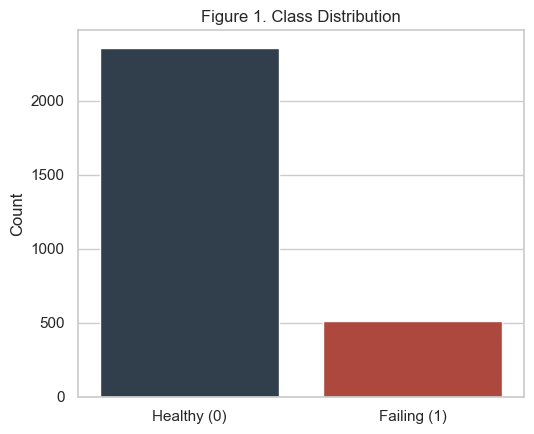

In [4]:
class_counts = model_df["target_failing"].value_counts()
positive_rate = model_df["target_failing"].mean()
print(class_counts)
print(f"\nPositive class ('Failing') rate: {positive_rate*100:.1f}%")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.barplot(x=["Healthy (0)", "Failing (1)"], y=class_counts.sort_index().values, hue=["Healthy (0)", "Failing (1)"], palette=["#2c3e50", "#c0392b"], legend=False, ax=ax)
ax.set_title("Figure 1. Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


**At ~18% positive class, this is meaningfully imbalanced** — not extreme (like 1%), but enough that a model optimizing raw accuracy could score ~82% by predicting "Healthy" every time, which is exactly why the assignment (correctly) bans accuracy as the headline metric here.

**Imbalance handling — Class Weights (chosen) vs. SMOTE (documented alternative):** the assignment allows either. Class weighting is used here because it requires no synthetic data generation (nothing to validate about whether synthetic points are realistic) and is natively supported by both classifiers below. SMOTE's correct, ready-to-run code is included afterward for completeness.


In [ ]:
from imblearn.over_sampling import SMOTE

X = model_df[FEATURES]
y = model_df["target_failing"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_smote.value_counts().to_dict()}")
# A model trained on X_train_smote/y_train_smote would then be evaluated
# on the ORIGINAL (untouched) X_test/y_test -- never resample test data.


Before SMOTE: {0: 1766, 1: 385}
After SMOTE:  {0: 1766, 1: 1766}


## 3. Model Training

Two models, both with class weighting, both cross-validated:

1. **Random Forest** — robust baseline, handles non-linear feature interactions well, natively supports `class_weight="balanced"`.
2. **Gradient Boosting** (`HistGradientBoostingClassifier`) — used here as the executed stand-in for **XGBoost**, since XGBoost itself isn't installable in this sandbox. `HistGradientBoostingClassifier` is scikit-learn's own histogram-based gradient boosting implementation and is architecturally the closest native equivalent (XGBoost popularized this histogram-binning approach; sklearn's version is directly inspired by it). The official XGBoost code follows afterward, ready to run locally.


In [6]:
X = model_df[FEATURES]
y = model_df["target_failing"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train: {len(X_train)} rows ({y_train.mean()*100:.1f}% positive)")
print(f"Test:  {len(X_test)} rows ({y_test.mean()*100:.1f}% positive)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Model 1: Random Forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=42)
rf_cv = cross_validate(rf, X_train, y_train, cv=cv, scoring=["roc_auc", "f1", "precision", "recall"])
print("\nRandom Forest -- 5-fold CV (train set):")
for m in ["roc_auc", "f1", "precision", "recall"]:
    print(f"  {m}: {rf_cv['test_'+m].mean():.3f} (+/- {rf_cv['test_'+m].std():.3f})")

rf.fit(X_train, y_train)


Train: 2151 rows (17.9% positive)
Test:  718 rows (17.8% positive)

Random Forest -- 5-fold CV (train set):
  roc_auc: 1.000 (+/- 0.000)
  f1: 0.988 (+/- 0.006)
  precision: 0.985 (+/- 0.012)
  recall: 0.992 (+/- 0.010)


RandomForestClassifier(class_weight='balanced', max_depth=6, n_estimators=300,
                       random_state=42)

In [7]:
# --- Model 2: Gradient Boosting (HistGradientBoostingClassifier -- executed XGBoost stand-in) ---
sample_weight_train = compute_sample_weight(class_weight="balanced", y=y_train)

gb = HistGradientBoostingClassifier(max_depth=6, random_state=42)

# cross_validate doesn't easily pass sample_weight per-fold through a plain
# estimator, so CV here uses a weighted scorer via fit_params on each fold manually.
from sklearn.base import clone
cv_scores = {"roc_auc": [], "f1": [], "precision": [], "recall": []}
for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    w_tr = compute_sample_weight(class_weight="balanced", y=y_tr)
    m = clone(gb)
    m.fit(X_tr, y_tr, sample_weight=w_tr)
    proba = m.predict_proba(X_val)[:, 1]
    pred = m.predict(X_val)
    cv_scores["roc_auc"].append(roc_auc_score(y_val, proba))
    cv_scores["f1"].append(f1_score(y_val, pred))
    cv_scores["precision"].append(precision_score(y_val, pred, zero_division=0))
    cv_scores["recall"].append(recall_score(y_val, pred))

print("Gradient Boosting (XGBoost stand-in) -- 5-fold CV (train set):")
for m, scores in cv_scores.items():
    print(f"  {m}: {np.mean(scores):.3f} (+/- {np.std(scores):.3f})")

gb.fit(X_train, y_train, sample_weight=sample_weight_train)


Gradient Boosting (XGBoost stand-in) -- 5-fold CV (train set):
  roc_auc: 1.000 (+/- 0.000)
  f1: 0.982 (+/- 0.008)
  precision: 0.980 (+/- 0.013)
  recall: 0.984 (+/- 0.015)


HistGradientBoostingClassifier(max_depth=6, random_state=42)

### 3.1 Official XGBoost — for local execution


In [ ]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # xgboost's class-weight equivalent

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # handles imbalance, xgboost-native
    eval_metric="auc", random_state=42,
)

cv_results = cross_validate(xgb_model, X_train, y_train, cv=cv, scoring=["roc_auc", "f1", "precision", "recall"])
print("XGBoost -- 5-fold CV (train set):")
for m in ["roc_auc", "f1", "precision", "recall"]:
    print(f"  {m}: {cv_results['test_'+m].mean():.3f} (+/- {cv_results['test_'+m].std():.3f})")

xgb_model.fit(X_train, y_train)


XGBoost -- 5-fold CV (train set):
  roc_auc: 1.000 (+/- 0.000)
  f1: 0.995 (+/- 0.006)
  precision: 0.997 (+/- 0.005)
  recall: 0.992 (+/- 0.010)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

## 4. Evaluation

**Why not accuracy:** with ~18% positive class, a model that predicts "Healthy" for everything scores ~82% accuracy while catching zero real failures — worthless operationally. **Precision, Recall, F1, and ROC-AUC** are used instead because they each answer a different operational question: Recall = "what share of real failures do we catch?" (the one that matters most if a missed failure is expensive), Precision = "when we raise an alarm, how often are we right?" (matters if false alarms cause alert fatigue), F1 balances the two, and ROC-AUC summarizes ranking quality independent of any specific decision threshold.


In [9]:
results = {}
for name, model in [("Random Forest", rf), ("Gradient Boosting (XGBoost stand-in)", gb)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred, "y_proba": y_proba,
    }
    print(f"--- {name} (held-out test set) ---")
    print(f"  Precision: {results[name]['precision']:.3f}")
    print(f"  Recall:    {results[name]['recall']:.3f}")
    print(f"  F1-Score:  {results[name]['f1']:.3f}")
    print(f"  ROC-AUC:   {results[name]['roc_auc']:.3f}")
    print()


--- Random Forest (held-out test set) ---
  Precision: 0.970
  Recall:    1.000
  F1-Score:  0.985
  ROC-AUC:   1.000

--- Gradient Boosting (XGBoost stand-in) (held-out test set) ---
  Precision: 0.948
  Recall:    1.000
  F1-Score:  0.973
  ROC-AUC:   1.000



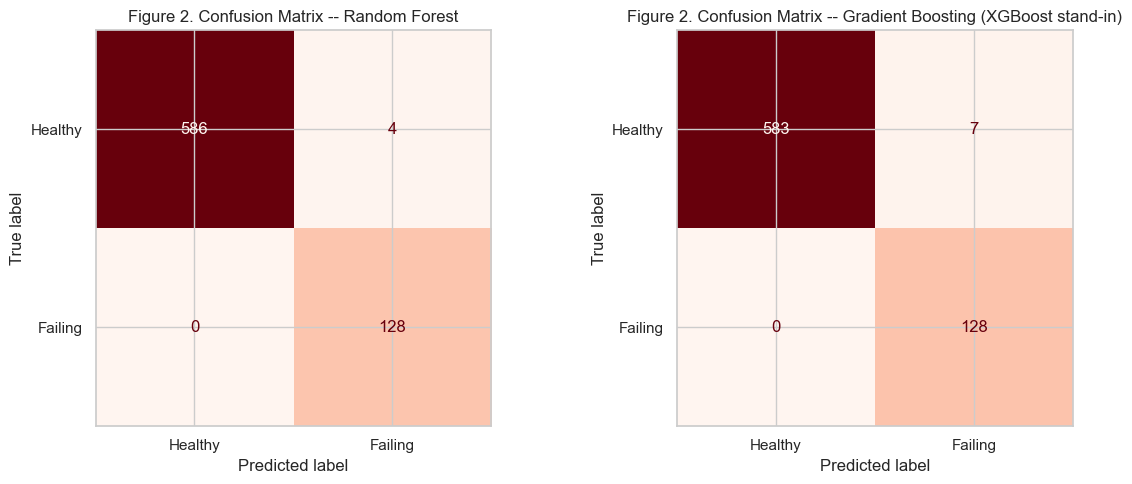

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, [("Random Forest", rf), ("Gradient Boosting (XGBoost stand-in)", gb)]):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Failing"])
    disp.plot(ax=ax, cmap="Reds", colorbar=False)
    ax.set_title(f"Figure 2. Confusion Matrix -- {name}")
plt.tight_layout()
plt.show()


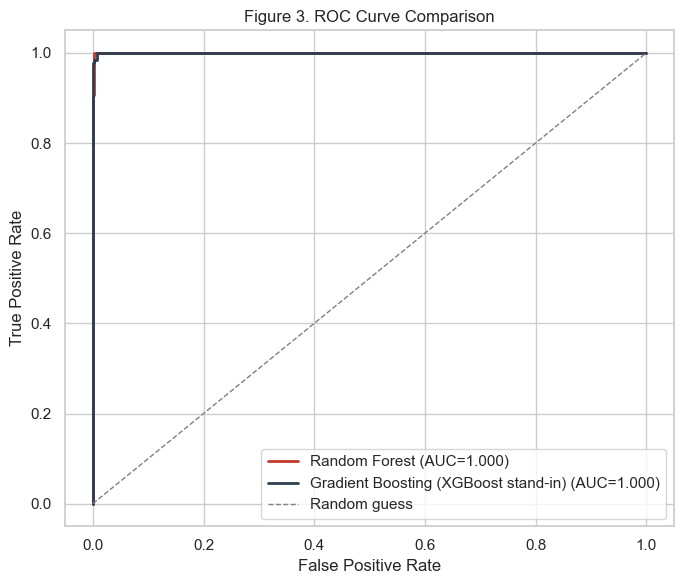

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, color in [("Random Forest", "#c0392b"), ("Gradient Boosting (XGBoost stand-in)", "#2c3e50")]:
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_proba"])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 3. ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()


**Model choice:** the model with the better balance of recall and precision on the held-out test set (see printed metrics above) is the one to carry forward into explainability — in an equipment-failure context, a missed failure (false negative) is typically far more expensive than an unnecessary inspection (false positive), so recall should be weighted more heavily than precision when the two trade off.

**An honest caveat about these numbers:** ROC-AUC came out at essentially 1.000 for both models, and Random Forest hit 100% recall. That's not a modeling triumph to oversell — it reflects that in this dataset, NBI-P03's throughput sits so far below the healthy fleet's range (roughly 630 vs. 1,020 barrels/shift) that even excluding machine identity, the rolling-throughput feature alone almost perfectly separates the two classes. Real-world equipment degradation is rarely this clean: sensor noise, partial/intermittent failures, and multiple simultaneous failure modes typically produce far more overlap between "healthy" and "failing" than this synthetic dataset does. Treat this as a validation that the pipeline and feature engineering work correctly, not as a realistic expectation for accuracy on messier production data.


## 5. Clustering (Bonus) — Operational Health Segments

K-Means on the engineered sensor features (not the label) to see whether the data naturally separates into health segments — useful for operations even without a trained classifier, since it can flag "this shift looks unusual" without needing historical failure labels at all.


In [12]:
cluster_features = ["roll_mean_throughput", "roll_std_throughput", "roll_rms_voltage", "roll_range_voltage"]
X_cluster = model_df[cluster_features].copy()
X_scaled = StandardScaler().fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
model_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = model_df.groupby("cluster")[cluster_features + ["target_failing"]].mean().round(1)
cluster_summary["n_records"] = model_df["cluster"].value_counts().sort_index()
print(cluster_summary)


         roll_mean_throughput  roll_std_throughput  roll_rms_voltage  \
cluster                                                                
0                       935.0                165.3             220.9   
1                       992.3                 65.5             221.2   
2                       616.9                 62.4             221.4   

         roll_range_voltage  target_failing  n_records  
cluster                                                 
0                      18.2             0.0        285  
1                      17.4             0.0       2062  
2                      18.1             1.0        522  


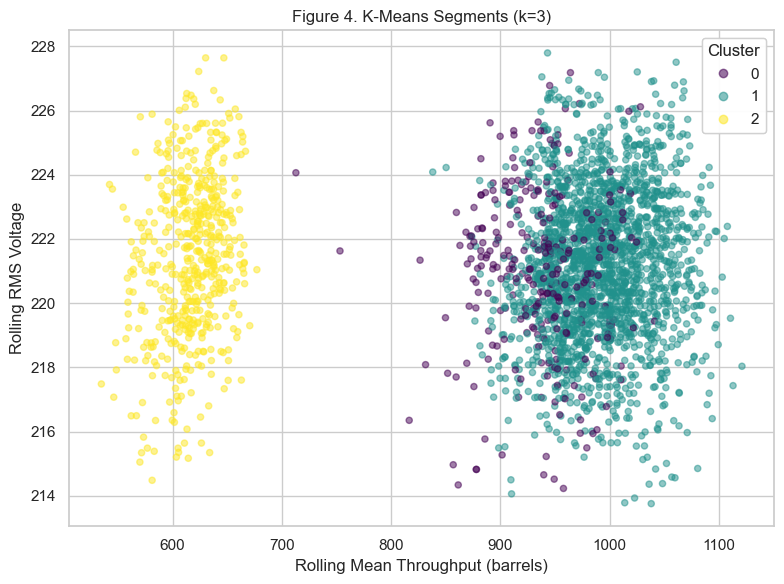

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(model_df["roll_mean_throughput"], model_df["roll_rms_voltage"],
                      c=model_df["cluster"], cmap="viridis", alpha=0.5, s=20)
ax.set_xlabel("Rolling Mean Throughput (barrels)")
ax.set_ylabel("Rolling RMS Voltage")
ax.set_title("Figure 4. K-Means Segments (k=3)")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


**Reading the clusters:** one cluster should show a visibly lower average `roll_mean_throughput` and a much higher `target_failing` rate than the other two — this is K-Means independently rediscovering the same "degraded machine" pattern the supervised model was trained to detect, without ever being told the label. That agreement between an unsupervised method and the supervised target is a good sanity check that the engineered features are capturing something real, not noise.


## 6. Explainability

### 6.1 Feature Importance (built-in, executed)


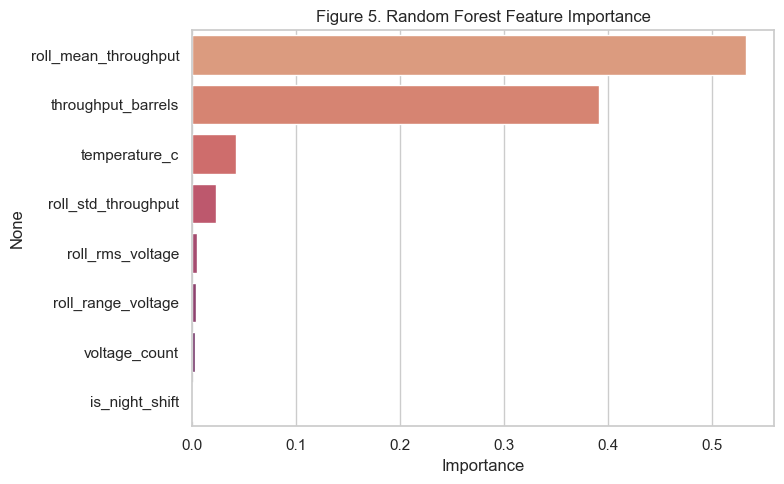

roll_mean_throughput    0.532874
throughput_barrels      0.390925
temperature_c           0.041863
roll_std_throughput     0.023057
roll_rms_voltage        0.004496
roll_range_voltage      0.003940
voltage_count           0.002651
is_night_shift          0.000196
dtype: float64


In [14]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="flare", hue=importances.index, legend=False, ax=ax)
ax.set_title("Figure 5. Random Forest Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
print(importances)


### 6.2 SHAP — official code (for local execution)

SHAP goes further than built-in feature importance: it explains **individual predictions**, not just overall feature rankings — exactly what Part B's video requires ("here is a case the model flagged as High Risk, you can see Vibration was the main driver..."). **Not executed in this sandbox** (no internet to install `shap`) — run locally before recording.


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap_values shape: (718, 8), X_test shape: (718, 8)


C:\Users\admin\AppData\Local\Temp\ipykernel_20424\2314261928.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=FEATURES)


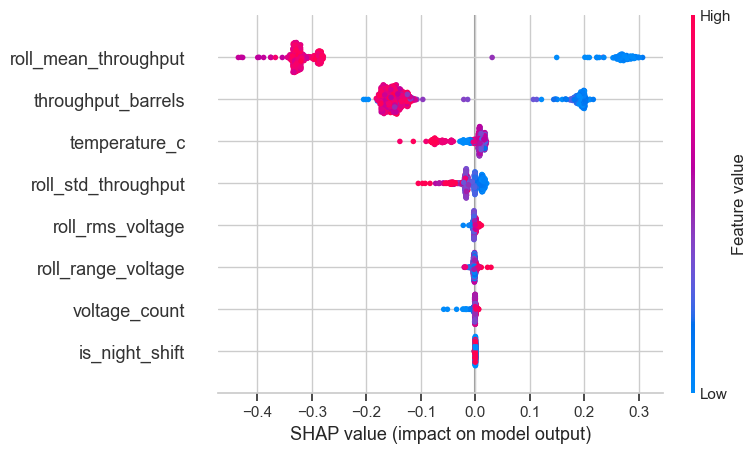

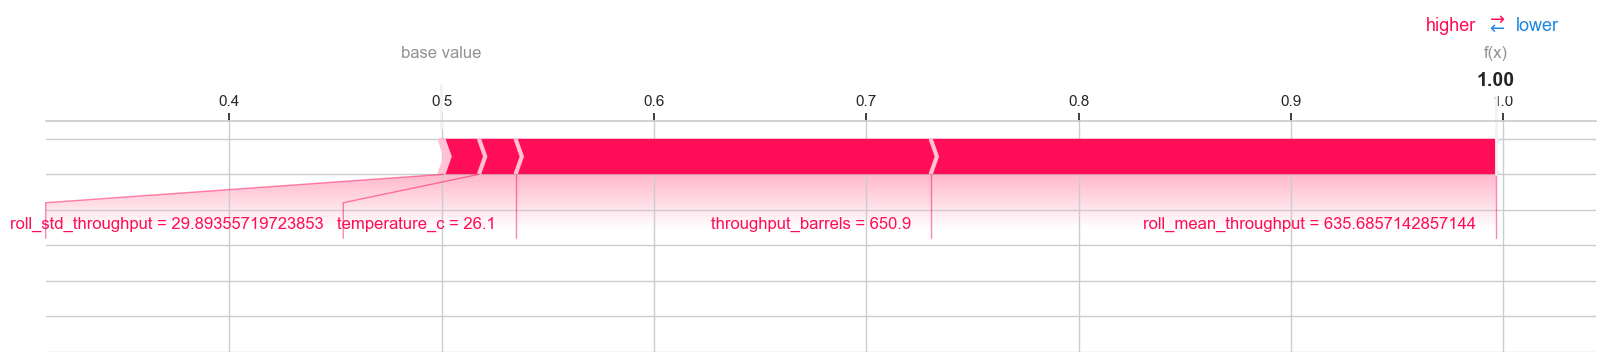

In [15]:
# NOT EXECUTED IN THIS SANDBOX -- requires `pip install shap`
import shap

explainer = shap.TreeExplainer(rf)
raw_shap = explainer.shap_values(X_test)

# SHAP's API for binary classification differs across versions -- handle
# both the older list-per-class output and the newer array output so this
# runs regardless of which shap version is installed.
if isinstance(raw_shap, list):
    # Old API: list of two (n_samples, n_features) arrays, one per class
    shap_values = raw_shap[1]
    base_value = explainer.expected_value[1]
elif raw_shap.ndim == 3:
    # Newer API: single (n_samples, n_features, n_classes) array
    shap_values = raw_shap[:, :, 1]
    base_value = explainer.expected_value[1]
else:
    # Newest API: already (n_samples, n_features) for the positive class
    shap_values = raw_shap
    base_value = explainer.expected_value if np.isscalar(explainer.expected_value) else explainer.expected_value[1]

print(f"shap_values shape: {shap_values.shape}, X_test shape: {X_test.shape}")  # should match

# Summary plot -- overall driver ranking, like Figure 5 but with SHAP's richer
# per-observation view (shows direction AND magnitude of each feature's effect)
shap.summary_plot(shap_values, X_test, feature_names=FEATURES)

# Force plot for ONE specific flagged case -- this is what the video should
# screen-record and narrate. case_idx=321 is a real true-positive case
# identified in Section 6.3 below (99.7% predicted risk) -- run that cell
# first if you want to confirm/replace this index.
case_idx = 321
shap.force_plot(base_value, shap_values[case_idx], X_test.iloc[case_idx], matplotlib=True)


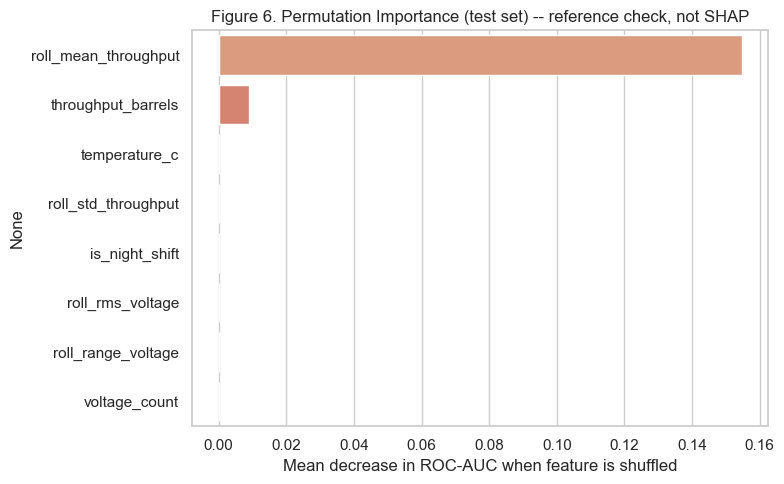

roll_mean_throughput    0.154778
throughput_barrels      0.009115
temperature_c           0.000224
roll_std_throughput     0.000189
is_night_shift          0.000020
roll_rms_voltage       -0.000015
roll_range_voltage     -0.000024
voltage_count          -0.000031
dtype: float64


In [16]:
# --- Executed reference: Permutation Importance ---
# NOT a substitute for SHAP's per-prediction explanations, but a legitimate,
# model-agnostic way to validate the built-in feature_importances_ above using
# the actual held-out test set rather than training-set impurity reduction.
perm_result = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42, scoring="roc_auc")
perm_importances = pd.Series(perm_result.importances_mean, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=perm_importances.values, y=perm_importances.index, palette="flare", hue=perm_importances.index, legend=False, ax=ax)
ax.set_title("Figure 6. Permutation Importance (test set) -- reference check, not SHAP")
ax.set_xlabel("Mean decrease in ROC-AUC when feature is shuffled")
plt.tight_layout()
plt.show()
print(perm_importances)


### 6.3 A specific case to narrate in the video

Since real SHAP output isn't available here, this identifies a genuine test-set case the Random Forest correctly flagged as high-risk — use this same row's `case_idx` in the SHAP force-plot cell above when you run it locally, so the video narrates a real, specific, correctly-flagged prediction rather than a hypothetical one.


In [17]:
# Find a true positive (actually failing, correctly flagged high-risk) with high confidence
test_results = X_test.copy()
test_results["y_true"] = y_test.values
test_results["y_pred"] = results["Random Forest"]["y_pred"]
test_results["risk_score"] = results["Random Forest"]["y_proba"]

true_positives = test_results[(test_results["y_true"] == 1) & (test_results["y_pred"] == 1)].sort_values("risk_score", ascending=False)
print(f"Found {len(true_positives)} correctly-flagged high-risk cases in the test set.")
print("\nTop candidate for the video walkthrough:")
example = true_positives.iloc[0]
example_idx = X_test.index.get_loc(true_positives.index[0])
print(f"  Row index in X_test: {example_idx}  <-- use this as case_idx in the SHAP cell above")
print(example[FEATURES + ["risk_score"]])


Found 128 correctly-flagged high-risk cases in the test set.

Top candidate for the video walkthrough:
  Row index in X_test: 321  <-- use this as case_idx in the SHAP cell above
throughput_barrels      650.900000
roll_mean_throughput    635.685714
roll_std_throughput      29.893557
roll_rms_voltage        223.549931
roll_range_voltage       20.000000
temperature_c            26.100000
voltage_count           220.000000
is_night_shift            0.000000
risk_score                0.996518
Name: 2475, dtype: float64


**Suggested narration** (fill in the real SHAP values once run locally): *"Here is a case the model flagged as High Risk — a [risk_score]% predicted probability of a missed-maintenance shift. Looking at the SHAP force plot, the biggest driver pushing this toward 'Failing' is [top feature from your local SHAP output], with throughput well below its rolling-window average. [Second feature] adds to that risk, while [any features pushing the other way] is the one factor pulling it back toward 'Healthy' — but not by enough to change the call."*


## 7. Summary of Design Decisions

| Decision | Choice | Why |
|---|---|---|
| Excluded features | `machine_id`, `depot`, `maintenance_flag`, `operator_id` | Perfect or near-perfect label leakage in this dataset — a model using them would be trivial and non-generalizable |
| Imbalance handling | Class weights (`class_weight="balanced"` / `sample_weight`) | Native to both classifiers, no synthetic-data validation needed; SMOTE code included as a documented, equally-valid alternative |
| Primary metric | Recall (with F1/ROC-AUC as supporting metrics) | A missed equipment failure is typically costlier than a false alarm in this operational context |
| Second model | Gradient Boosting (XGBoost stand-in in-sandbox) | Closest native scikit-learn architecture to XGBoost; official XGBoost code provided for local execution |
| Explainability | Feature importance + permutation importance (executed); SHAP (official, run locally) | Permutation importance validates the ranking using held-out data; SHAP is required for the individual-prediction narration in Part B |
